# Quantum-gated ResNet18 — Diabetic Retinopathy (Gaussian-filtered) (5 classes)

Adapted directly from your uploaded **gated_srivathsa.ipynb**. [Dataset source](https://www.kaggle.com/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered).

**Unchanged:** QuantumGatedResNet source, gate after layer3, 512-feature head input, two qubits / two circuit layers, CPU quantum simulation workaround, ImageNet pretrained ResNet18, RGB resize and normalization, zoom-only augmentation on the training split, ordinary shuffled batches, unweighted cross-entropy, Adam, seed 42, batch size 32, maximum 20 epochs, learning rate 5e-5, patience 5, validation macro-F1 selection, Grad-CAM, and gate visualizations.

**Dataset-specific changes only:** loading/labels; NUM_CLASSES=5; output names; removal of HAM10000 lesion metadata. 

**Labels in head order:** 0=No_DR, 1=Mild, 2=Moderate, 3=Severe, 4=Proliferate_DR.

**Split:** seeded image-level random_split 70/15/15 of labeled train.csv images. Same split proportions and seeded random_split method as your uploaded skin notebook.

**Same architecture, separate model:** each dataset starts fresh from ImageNet weights, as in your notebook. No skin-cancer checkpoint is loaded. These files do not create one combined multi-dataset classifier. Use a fresh session for each notebook.

Image-level splits do not establish patient-level independence: these loaders have no verified patient grouping metadata. Results are for research, not clinical validation. No artificial patient/lesion IDs are generated.

## Run
1. Import into Kaggle and attach **sovitrath/diabetic-retinopathy-224x224-gaussian-filtered** using Add Input.
2. Enable GPU and Internet; run from the top.
3. If automatic discovery fails, set DATA_ROOT_OVERRIDE in the configuration cell to the dataset root shown in Input.
4. Let the smoke check pass before training.
5. Download the final ZIP before stopping the session.

Class mappings and split manifests are saved. Old skin-cancer outputs are cleared; no new training results are claimed. The only augmentation added here is training-time zoom via RandomResizedCrop with fixed 1:1 aspect ratio.

In [1]:
%pip install -q pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 94.6 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 64.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 98.7 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import copy
import glob
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)

import pennylane as qml

# Retained training settings; revised split and architecture must match other tracks.
DATASET_HANDLE = "sovitrath/diabetic-retinopathy-224x224-gaussian-filtered"
DATA_ROOT_OVERRIDE = None  # Optional exact dataset-root path shown in Input.

N_QUBITS   = 2       # retained qubit count
N_QLAYERS  = 2        # retained circuit depth
IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
SEED = 42

# Fixed class order for Diabetic Retinopathy (Gaussian-filtered).
CLASS_NAMES = ["No_DR","Mild","Moderate","Severe","Proliferate_DR"]
NUM_CLASSES = len(CLASS_NAMES)
LABEL_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

def round3(d):
    """Round every numeric value in a dict to 3 decimal places for reporting."""
    out = {}
    for k, v in d.items():
        if isinstance(v, (int, float, np.floating)) and not (isinstance(v, float) and np.isnan(v)):
            out[k] = round(float(v), 3)
        else:
            out[k] = v
    return out
from pathlib import Path
from datetime import datetime, timezone
import json
import uuid

FULL_EPOCHS = 20
LR = 5e-5
PATIENCE = 5
RUN_DIR = Path("/kaggle/working/checkpoints") / (
    "quantum_gated_diabetic_retinopathy_" + datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
    + "_" + uuid.uuid4().hex[:8]
)
RUN_DIR.mkdir(parents=True, exist_ok=False)
print("Output directory:", RUN_DIR)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CPU runtime; full training may be slow.")

Using device: cuda
Output directory: /kaggle/working/checkpoints/quantum_gated_diabetic_retinopathy_20260903_132627_b57e109d
GPU: Tesla T4


## 1. Transforms (zoom-only training augmentation)
Keep ImageNet normalization for the pretrained ResNet. Apply **only zoom augmentation** to the training split; validation and test remain deterministic.


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Zoom-only augmentation: randomly crop 80%-100% of the image area at a fixed
# 1:1 aspect ratio, then resize back to IMG_SIZE. No flip/rotation/color/etc.
train_transform = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.00), ratio=(1.0, 1.0)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Validation/test: no augmentation.
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


## 2. Dataset definition
Validate folder/CSV labels and retain RGB conversion for the unchanged ResNet input.

In [5]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

def resolve_dataset_root():
    if DATA_ROOT_OVERRIDE:
        root = Path(DATA_ROOT_OVERRIDE)
        if not root.is_dir():
            raise FileNotFoundError(f"DATA_ROOT_OVERRIDE does not exist: {root}")
        return root
    owner, slug = DATASET_HANDLE.split("/")
    candidates = [Path("/kaggle/input/datasets") / owner / slug, Path("/kaggle/input") / slug]
    found = {p.resolve() for p in candidates if p.is_dir()}
    if len(found) != 1:
        raise FileNotFoundError(
            f"Attach {DATASET_HANDLE} with Add Input, or set DATA_ROOT_OVERRIDE "
            f"to the exact dataset root shown in Input. Checked: {candidates}"
        )
    return found.pop()

def find_class_parent(root, class_names):
    candidates = [root] + sorted(p for p in root.rglob("*") if p.is_dir())
    matches = [p for p in candidates if all((p / name).is_dir() for name in class_names)]
    if len(matches) != 1:
        raise ValueError(f"Expected one parent for {class_names}; found {matches}")
    return matches[0]

def folder_rows(class_parent, root, source_subset):
    rows = []
    unexpected = [p.name for p in class_parent.iterdir()
                  if p.is_dir() and not p.name.startswith(".") and p.name not in CLASS_NAMES]
    if unexpected:
        raise ValueError(f"Unexpected class folders in {class_parent}: {unexpected}")
    for cls in CLASS_NAMES:
        folder = class_parent / cls
        files = sorted(p for p in folder.rglob("*")
                       if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
        if not files:
            raise ValueError(f"No images found in {folder}")
        for p in files:
            if any("mask" in part.lower() for part in p.relative_to(folder).parts[:-1]):
                raise ValueError(f"Mask directory detected: {p}; select image-only data.")
            rows.append({
                "image_id": p.relative_to(root).as_posix(),
                "class_name": cls, "label": LABEL_TO_IDX[cls],
                "filepath": str(p), "source_subset": source_subset,
            })
    return rows

def load_metadata(root):
    csv_candidates = sorted(root.rglob("train.csv"))
    if len(csv_candidates) != 1:
        raise FileNotFoundError(f"Expected one train.csv; found {csv_candidates}")
    metadata = pd.read_csv(csv_candidates[0], dtype={"id_code": str})
    if not {"id_code", "diagnosis"}.issubset(metadata.columns):
        raise ValueError("train.csv must contain id_code and diagnosis.")
    if metadata[["id_code", "diagnosis"]].isna().any().any():
        raise ValueError("Missing image ID or diagnosis in train.csv.")
    if metadata["id_code"].duplicated().any():
        raise ValueError("Duplicate id_code rows in train.csv.")
    numeric_labels = pd.to_numeric(metadata["diagnosis"], errors="raise")
    if not numeric_labels.isin(range(NUM_CLASSES)).all():
        raise ValueError("Expected integer diagnosis labels 0 through 4.")
    metadata["label"] = numeric_labels.astype(int)
    class_parent = find_class_parent(root, CLASS_NAMES)
    image_rows = folder_rows(class_parent, root, "labeled_train_csv")
    lookup = {}
    for item in image_rows:
        stem = Path(item["filepath"]).stem
        if stem in lookup:
            raise ValueError(f"Ambiguous image ID: {stem}")
        lookup[stem] = item
    rows = []
    for record in metadata.itertuples(index=False):
        image_id = record.id_code
        if image_id not in lookup:
            raise FileNotFoundError(f"CSV image missing from Gaussian-filtered folders: {image_id}")
        item = dict(lookup[image_id])
        if item["class_name"] != CLASS_NAMES[record.label]:
            raise ValueError(f"Folder/CSV label conflict for {image_id}")
        item["image_id"] = image_id
        rows.append(item)
    extra = set(lookup) - set(metadata["id_code"])
    if extra:
        print(f"Excluded {len(extra)} images not labeled by train.csv (no invented labels).")
    return pd.DataFrame(rows)

class MedicalImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.df = load_metadata(Path(root)).reset_index(drop=True)
        required = ["image_id", "class_name", "label", "filepath", "source_subset"]
        if self.df.empty or self.df[required].isna().any().any():
            raise ValueError("Empty dataset or missing metadata.")
        if self.df["image_id"].duplicated().any() or self.df["filepath"].duplicated().any():
            raise ValueError("Duplicate image identifiers or paths.")
        if not self.df["class_name"].isin(CLASS_NAMES).all():
            raise ValueError("Unknown class label.")
        if not self.df["label"].equals(self.df["class_name"].map(LABEL_TO_IDX)):
            raise ValueError("Numeric labels do not match the fixed class mapping.")
        self.classes = list(CLASS_NAMES)
        self.class_to_idx = dict(LABEL_TO_IDX)
        self.transform = transform
        print(f"Total labeled images: {len(self.df)}")
        print(self.df["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0))

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["filepath"]) as image:
            image = image.convert("RGB")
            if self.transform is not None:
                image = self.transform(image)
        return image, int(row["label"])

## 3. Dataset → train / validation / test → loaders
seeded image-level random_split 70/15/15 of labeled train.csv images. No oversampling or loss weighting. Test data is never used for early stopping.

In [6]:
DATA_ROOT = resolve_dataset_root()
print("Dataset root:", DATA_ROOT)

# Build matching dataset views so only the training split receives zoom augmentation.
base_dataset = MedicalImageDataset(DATA_ROOT, eval_transform)
train_view = MedicalImageDataset(DATA_ROOT, train_transform)
eval_view = MedicalImageDataset(DATA_ROOT, eval_transform)
assert base_dataset.df[["image_id", "label"]].equals(train_view.df[["image_id", "label"]])
assert base_dataset.df[["image_id", "label"]].equals(eval_view.df[["image_id", "label"]])
full_dataset = eval_view  # canonical metadata + deterministic transform for reporting/visualization

train_size = int(0.70 * len(base_dataset))
val_size = int(0.15 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size

# Generate the exact same seeded split indices as the baseline notebook.
base_train, base_val, base_test = random_split(
    base_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED),
)
train_dataset = Subset(train_view, base_train.indices)
val_dataset = Subset(eval_view, base_val.indices)
test_dataset = Subset(eval_view, base_test.indices)

subsets = {"train": train_dataset, "validation": val_dataset, "test": test_dataset}
manifest_parts = []
index_sets = [set(subset.indices) for subset in subsets.values()]
assert not (index_sets[0] & index_sets[1] or index_sets[0] & index_sets[2] or index_sets[1] & index_sets[2])
assert len(set.union(*index_sets)) == len(full_dataset)
for split, subset in subsets.items():
    rows = full_dataset.df.iloc[subset.indices].copy()
    rows["split"] = split
    manifest_parts.append(rows)
    counts = rows["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
    print(f"\n{split}: {len(subset)} images\n{counts}")
    if (counts == 0).any():
        raise ValueError(f"{split} lacks a class; agree on a revised split before training.")
manifest = pd.concat(manifest_parts, ignore_index=True)
manifest[["image_id", "class_name", "label", "source_subset", "split"]].to_csv(
    RUN_DIR / "split_manifest.csv", index=False
)
print("Image-level partitions only; patient-level independence is not verified.")
print("Training augmentation: zoom only (RandomResizedCrop scale=0.80-1.00, ratio=1:1).")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
    generator=torch.Generator().manual_seed(SEED),
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
)
print("Batches:", len(train_loader), len(val_loader), len(test_loader))


Dataset root: /kaggle/input/datasets/sovitrath/diabetic-retinopathy-224x224-gaussian-filtered
Total labeled images: 3662
class_name
No_DR             1805
Mild               370
Moderate           999
Severe             193
Proliferate_DR     295
Name: count, dtype: int64
Total labeled images: 3662
class_name
No_DR             1805
Mild               370
Moderate           999
Severe             193
Proliferate_DR     295
Name: count, dtype: int64
Total labeled images: 3662
class_name
No_DR             1805
Mild               370
Moderate           999
Severe             193
Proliferate_DR     295
Name: count, dtype: int64

train: 2563 images
class_name
No_DR             1285
Mild               244
Moderate           693
Severe             132
Proliferate_DR     209
Name: count, dtype: int64

validation: 549 images
class_name
No_DR             246
Mild               57
Moderate          164
Severe             34
Proliferate_DR     48
Name: count, dtype: int64

test: 550 images
class_na

## 4. Quantum layer — retained 2-qubit circuit

In [7]:
q_device = qml.device("default.qubit", wires=N_QUBITS)

def _circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    qml.BasicEntanglerLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

qnode = qml.QNode(_circuit, q_device, interface="torch", diff_method="backprop")
weight_shapes = {"weights": (N_QLAYERS, N_QUBITS)}

def make_quantum_layer():
    return qml.qnn.TorchLayer(qnode, weight_shapes)

## 5. Quantum-gated ResNet18
Unchanged model code; 512 features enter the head, which outputs 5 logits through NUM_CLASSES.

In [8]:
class QuantumGatedResNet(nn.Module):
    def __init__(self, pretrained=True, freeze_stem=False):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)

        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3   # quantum gate taps here -> 256 channels
        self.layer4 = resnet.layer4
        self.avgpool = resnet.avgpool

        if freeze_stem:
            for p in self.stem.parameters():
                p.requires_grad = False

        GATE_CHANNELS = 256
        self.squeeze = nn.Sequential(
            nn.Linear(GATE_CHANNELS, 32), nn.ReLU(), nn.Linear(32, N_QUBITS), nn.Tanh()
        )
        self.quantum = make_quantum_layer()
        self.excite = nn.Sequential(nn.Linear(N_QUBITS, GATE_CHANNELS), nn.Sigmoid())

        self.head = nn.Linear(512, NUM_CLASSES)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)                                            # (B, 256, H, W)

        pooled = x.mean(dim=[2, 3])
        q_in = self.squeeze(pooled) * np.pi
        q_out = self.quantum(q_in.to(device="cpu", dtype=torch.float32))
        q_out = q_out.to(device=x.device, dtype=x.dtype)
        gate = self.excite(q_out).unsqueeze(-1).unsqueeze(-1)  # (B, 256, 1, 1)

        x = x * gate
        x = self.layer4(x)
        x = self.avgpool(x).flatten(1)
        return self.head(x)

## 6. Architecture checks
The smoke test verifies 5 logits and finite, nonzero gradients through the visual and quantum-gating branches.

In [9]:
assert callable(QuantumGatedResNet)
print(f"Final head: 512 visual features -> {NUM_CLASSES} classes; quantum branch gates layer3.")

Final head: 512 visual features -> 5 classes; quantum branch gates layer3.


## 7. Forward/backward smoke check
Uses a disposable unpretrained model and synthetic inputs. Checks both branches receive finite, nonzero gradients; this does not measure training quality.

In [10]:
with torch.random.fork_rng(devices=list(range(torch.cuda.device_count()))):
    torch.manual_seed(SEED)
    smoke_model = QuantumGatedResNet(pretrained=False).to(DEVICE).eval()
    smoke_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
    smoke_y = torch.tensor([0, 1], device=DEVICE)
    smoke_logits = smoke_model(smoke_x)
    assert smoke_logits.shape == (2, NUM_CLASSES)
    assert smoke_model.head.in_features == 512
    smoke_loss = nn.CrossEntropyLoss()(smoke_logits, smoke_y)
    assert torch.isfinite(smoke_loss)
    smoke_loss.backward()
    for name, module in [("stem", smoke_model.stem),
                         ("layer3", smoke_model.layer3),
                         ("layer4", smoke_model.layer4),
                         ("squeeze", smoke_model.squeeze),
                         ("quantum", smoke_model.quantum),
                         ("excite", smoke_model.excite),
                         ("head", smoke_model.head)]:
        grads = [p.grad for p in module.parameters() if p.requires_grad]
        assert grads and all(g is not None and torch.isfinite(g).all() for g in grads), name
        assert sum(g.abs().sum().item() for g in grads) > 0, name
    print("PASS: output shape, finite loss, and gradients through visual and quantum-gating branches.")
    del smoke_model, smoke_x, smoke_y, smoke_logits, smoke_loss, grads, module
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

PASS: output shape, finite loss, and gradients through visual and quantum-gating branches.


## 8. Training and evaluation utilities — unweighted cross-entropy

In [11]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_probs, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs)
        loss = criterion(logits, labels)
        running_loss += loss.item() * imgs.size(0)
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy().tolist())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.array(all_labels)
    preds = all_probs.argmax(axis=1)

    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_labels, preds),
        "precision_macro": precision_score(all_labels, preds, average="macro", zero_division=0),
        "recall_macro": recall_score(all_labels, preds, average="macro", zero_division=0),
        "f1_macro": f1_score(all_labels, preds, average="macro", zero_division=0),
        "auc_macro_ovr": auc,
    }
    return metrics, all_probs, all_labels

def run_training(model, train_loader, val_loader, epochs, lr,
                  early_stopping=True, patience=5, monitor="f1_macro", min_delta=1e-4, verbose=True, checkpoint_path=None):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_f1": []}
    best_score, best_state, best_epoch, epochs_no_improve = -float("inf"), None, 0, 0

    for epoch in range(epochs):
        t0 = time.time()
        tr_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics, _, _ = evaluate(model, val_loader, criterion)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_auc"].append(val_metrics["auc_macro_ovr"])
        history["val_f1"].append(val_metrics["f1_macro"])

        current = val_metrics[monitor]
        improved = current > best_score + min_delta
        flag = ""
        if improved:
            best_score, best_state, best_epoch, epochs_no_improve = current, {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, epoch + 1, 0
            if checkpoint_path is not None:
                torch.save(best_state, checkpoint_path)
            flag = "  <- best so far"
        else:
            epochs_no_improve += 1

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} | train_loss={tr_loss:.3f} | val_loss={val_metrics['loss']:.3f} "
                  f"| val_acc={val_metrics['accuracy']:.3f} | val_auc={val_metrics['auc_macro_ovr']:.3f} "
                  f"| val_f1={val_metrics['f1_macro']:.3f} | {time.time()-t0:.1f}s{flag}")

        if early_stopping and epochs_no_improve >= patience:
            if verbose:
                print(f"Early stopping after epoch {epoch+1} (no improvement in {monitor} for {patience} epochs). "
                      f"Restoring weights from epoch {best_epoch}.")
            break

    if early_stopping and best_state is not None:
        model.load_state_dict(best_state)
    return model, history

## 9. Train the main model
20-epoch maximum; select best validation macro-F1, stop after five non-improving epochs. Best weights are saved as soon as improvement occurs (weights-only, not an optimizer-resume checkpoint).

In [12]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

BEST_PATH = RUN_DIR / "quantum_gated_diabetic_retinopathy_resnet18_2q.pt"
print("Training with ordinary shuffled batches and unweighted CrossEntropyLoss.")
gated_model = QuantumGatedResNet(pretrained=True, freeze_stem=False)
gated_model, gated_history = run_training(
    gated_model, train_loader, val_loader, FULL_EPOCHS, LR,
    early_stopping=True, patience=PATIENCE, monitor="f1_macro",
    checkpoint_path=BEST_PATH,
)
history_df = pd.DataFrame(gated_history)
history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
history_df.to_csv(RUN_DIR / "training_history.csv", index=False)

Training with ordinary shuffled batches and unweighted CrossEntropyLoss.
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


Epoch 1/20 | train_loss=0.766 | val_loss=0.682 | val_acc=0.750 | val_auc=0.894 | val_f1=0.513 | 15.1s  <- best so far
Epoch 2/20 | train_loss=0.539 | val_loss=0.633 | val_acc=0.758 | val_auc=0.912 | val_f1=0.589 | 9.9s  <- best so far
Epoch 3/20 | train_loss=0.434 | val_loss=0.656 | val_acc=0.754 | val_auc=0.912 | val_f1=0.556 | 9.9s
Epoch 4/20 | train_loss=0.357 | val_loss=0.630 | val_acc=0.767 | val_auc=0.920 | val_f1=0.591 | 10.2s  <- best so far
Epoch 5/20 | train_loss=0.285 | val_loss=0.634 | val_acc=0.756 | val_auc=0.916 | val_f1=0.554 | 10.3s
Epoch 6/20 | train_loss=0.227 | val_loss=0.737 | val_acc=0.765 | val_auc=0.899 | val_f1=0.567 | 10.3s
Epoch 7/20 | train_loss=0.187 | val_loss=0.736 | val_acc=0.765 | val_auc=0.916 | val_f1=0.600 | 10.5s  <- best so far
Epoch 8/20 | train_loss=0.137 | val_loss=0.692 | val_acc=0.765 | val_auc=0.914 | val_f1=0.620 | 10.5s  <- best so far
Epoch 9/20 | train_loss=0.127 | val_loss=0.766 | val_acc=0.776 | val_auc=0.913 | val_f1=0.624 | 10.4s  <- 

## 10. Training curves

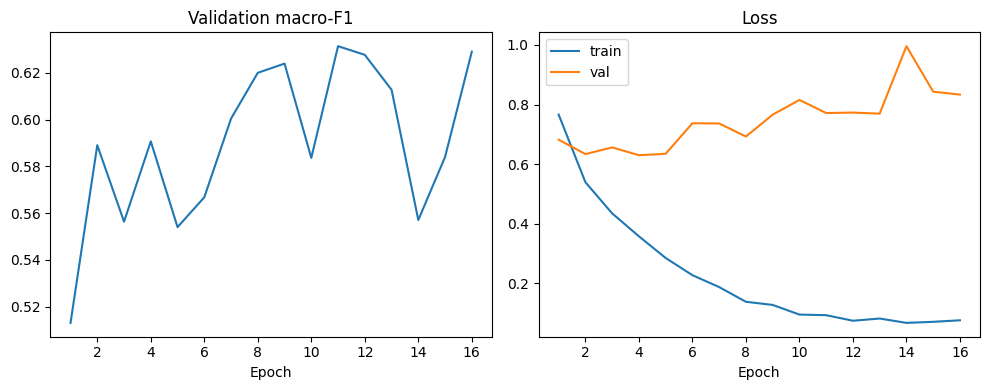

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
epochs_axis = range(1, len(gated_history["val_f1"]) + 1)
axes[0].plot(epochs_axis, gated_history["val_f1"]); axes[0].set_title("Validation macro-F1"); axes[0].set_xlabel("Epoch")
axes[1].plot(epochs_axis, gated_history["train_loss"], label="train"); axes[1].plot(epochs_axis, gated_history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.savefig(RUN_DIR / "training_curves.png", dpi=160)
plt.show()

## 11. Final validation and held-out image-level test evaluation
The model has restored the validation-selected weights. Do not tune using test results. Patient-level independence has not been verified.


=== VALIDATION metrics ===
{'loss': 0.771, 'accuracy': 0.776, 'precision_macro': 0.643, 'recall_macro': 0.631, 'f1_macro': 0.631, 'auc_macro_ovr': 0.911}
                precision    recall  f1-score   support

         No_DR      0.956     0.972     0.964       246
          Mild      0.561     0.561     0.561        57
      Moderate      0.717     0.726     0.721       164
        Severe      0.386     0.500     0.436        34
Proliferate_DR      0.594     0.396     0.475        48

      accuracy                          0.776       549
     macro avg      0.643     0.631     0.631       549
  weighted avg      0.777     0.776     0.774       549



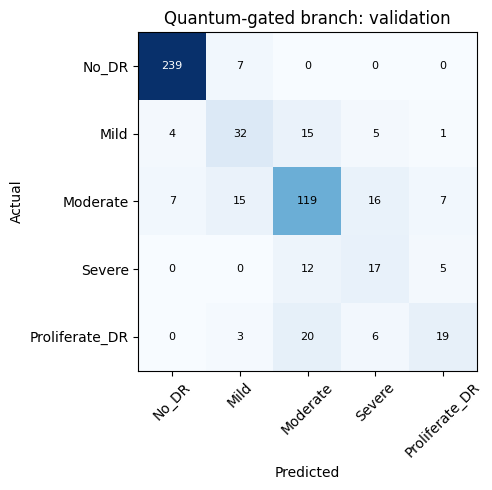


=== TEST metrics ===
{'loss': 0.602, 'accuracy': 0.835, 'precision_macro': 0.71, 'recall_macro': 0.655, 'f1_macro': 0.669, 'auc_macro_ovr': 0.917}
                precision    recall  f1-score   support

         No_DR      0.964     0.982     0.973       274
          Mild      0.714     0.652     0.682        69
      Moderate      0.741     0.845     0.789       142
        Severe      0.464     0.481     0.473        27
Proliferate_DR      0.667     0.316     0.429        38

      accuracy                          0.835       550
     macro avg      0.710     0.655     0.669       550
  weighted avg      0.830     0.835     0.827       550



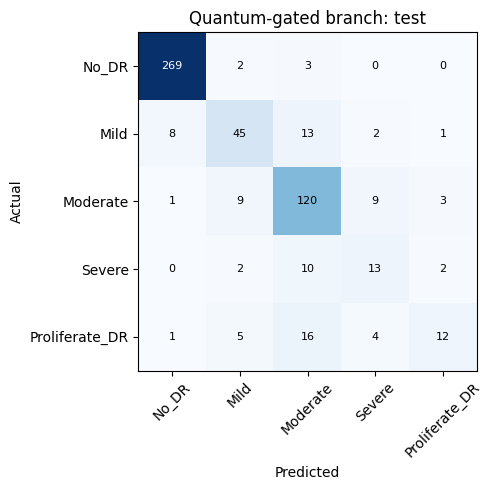

In [14]:
criterion = nn.CrossEntropyLoss()
metrics_rows = []
for split, loader, subset in [
    ("validation", val_loader, val_dataset),
    ("test", test_loader, test_dataset),
]:
    metrics, probs, labels = evaluate(gated_model, loader, criterion)
    preds = probs.argmax(axis=1)
    metrics_rows.append({"model": "Quantum-gated branch", "dataset": DATASET_HANDLE, "split": split, **metrics})
    print(f"\n=== {split.upper()} metrics ===")
    print(round3(metrics))
    print(classification_report(
        labels, preds, labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES,
        digits=3, zero_division=0,
    ))
    report = classification_report(
        labels, preds, labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES,
        output_dict=True, zero_division=0,
    )
    pd.DataFrame(report).transpose().to_csv(RUN_DIR / f"{split}_classification_report.csv")
    prediction_df = full_dataset.df.iloc[subset.indices][["image_id", "source_subset"]].reset_index(drop=True)
    prediction_df["true_label"] = labels
    prediction_df["predicted_label"] = preds
    for i, cls in enumerate(CLASS_NAMES):
        prediction_df[f"prob_{cls}"] = probs[:, i]
    prediction_df.to_csv(RUN_DIR / f"{split}_predictions.csv", index=False)
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45)
    ax.set_yticks(range(NUM_CLASSES), CLASS_NAMES)
    ax.set(xlabel="Predicted", ylabel="Actual", title=f"Quantum-gated branch: {split}")
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout()
    plt.savefig(RUN_DIR / f"{split}_confusion_matrix.png", dpi=160)
    plt.show()
pd.DataFrame(metrics_rows).to_csv(RUN_DIR / "quantum_gated_diabetic_retinopathy_metrics.csv", index=False)

## 12. Export deployment artifacts and verify backend inference\n\nThe deployment ZIP contains only the model weights and reconstruction manifest.\n

In [ ]:
# Export the restored best-validation model and backend inference manifest.
import shutil
import torchvision
from pathlib import Path
from IPython.display import FileLink, display

DEPLOY_DIR = Path("/kaggle/working/diabetic_retinopathy_backend_model")
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = DEPLOY_DIR / "diabetic_retinopathy_model.pth"
CONFIG_PATH = DEPLOY_DIR / "diabetic_retinopathy_config.json"
ZIP_PATH = Path("/kaggle/working/diabetic_retinopathy_backend_model.zip")

# gated_model was restored to the validation-selected best state by run_training.
torch.save(
    {key: value.detach().cpu() for key, value in gated_model.state_dict().items()},
    MODEL_PATH,
)

config = {
    "model_name": "QuantumGatedResNet",
    "architecture": "Quantum-gated torchvision ResNet18",
    "backbone": "ResNet18",
    "class_names": CLASS_NAMES,
    "class_to_index": LABEL_TO_IDX,
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "input_channels": 3,
    "rgb_required": True,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "inference_resize_rule": "Resize((IMG_SIZE, IMG_SIZE))",
    "inference_transform_order": [
        "PIL.Image.convert('RGB')",
        "Resize((IMG_SIZE, IMG_SIZE))",
        "ToTensor()",
        "Normalize(IMAGENET_MEAN, IMAGENET_STD)",
    ],
    "training_augmentation": "RandomResizedCrop(IMG_SIZE, scale=(0.80, 1.00), ratio=(1.0, 1.0))",
    "training_augmentation_inference_rule": "Do not use training augmentation for inference.",
    "n_qubits": N_QUBITS,
    "n_quantum_layers": N_QLAYERS,
    "pennylane_device": "default.qubit",
    "quantum_embedding": "qml.AngleEmbedding",
    "quantum_circuit_type": "qml.BasicEntanglerLayers with PauliZ expectation values",
    "quantum_gate_location": "after ResNet18 layer3",
    "gate_channels": 256,
    "representation_before_classifier": 512,
    "seed": SEED,
    "split": "seeded image-level random_split 70/15/15 of labeled train.csv images",
    "output_type": "logits",
    "probability_operation": "softmax",
    "best_epoch": gated_model.best_epoch,
    "best_validation_macro_f1": gated_model.best_validation_f1,
    "pytorch_version": torch.__version__,
    "torchvision_version": torchvision.__version__,
    "pennylane_version": qml.__version__,
}
CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding="utf-8")

if ZIP_PATH.exists():
    ZIP_PATH.unlink()
shutil.make_archive(
    str(ZIP_PATH.with_suffix("")),
    "zip",
    root_dir=DEPLOY_DIR.parent,
    base_dir=DEPLOY_DIR.name,
)

print("Deployment files:")
for path in (MODEL_PATH, CONFIG_PATH, ZIP_PATH):
    print(path.resolve())
print(f"Download this ZIP from Kaggle: {ZIP_PATH.resolve()}")
display(FileLink(ZIP_PATH, result_html_prefix="Kaggle download link: "))

# Fresh-load backend simulation using only deterministic evaluation preprocessing.
reloaded_config = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
reloaded_model = QuantumGatedResNet(pretrained=False, freeze_stem=False)
reloaded_model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
reloaded_model.eval()

inference_transform = T.Compose([
    T.Resize((reloaded_config["img_size"], reloaded_config["img_size"])),
    T.ToTensor(),
    T.Normalize(reloaded_config["imagenet_mean"], reloaded_config["imagenet_std"]),
])
raw_image_path = full_dataset.df.iloc[0]["filepath"]
with Image.open(raw_image_path) as raw_image:
    image_tensor_cpu = inference_transform(raw_image.convert("RGB")).unsqueeze(0)

gated_model.eval()
with torch.no_grad():
    original_logits = gated_model(image_tensor_cpu.to(DEVICE)).cpu()
    reloaded_logits = reloaded_model(image_tensor_cpu)
    probabilities = torch.softmax(reloaded_logits, dim=1)

np.testing.assert_allclose(
    original_logits.numpy(), reloaded_logits.numpy(), rtol=1e-5, atol=1e-6
)
np.testing.assert_allclose(probabilities.sum(dim=1).numpy(), np.ones(1), atol=1e-6)
predicted_class = int(probabilities.argmax(dim=1).item())
print("Smoke test passed: reloaded CPU model matches the restored best model.")
for class_name, probability in zip(reloaded_config["class_names"], probabilities[0].tolist()):
    print(f"{class_name}: {probability}")
print("Predicted class:", reloaded_config["class_names"][predicted_class])


## 13. Explainability: Grad-CAM and quantum-controlled gate values

Uses a fixed sample of validation images, never test images. Grad-CAM is computed for the predicted logit. Hooks are removed after use so rerunning the cell does not accumulate hooks. Main training results are saved before this section.

Gate values near zero attenuate a channel; values near one preserve it. The learned classical excitation layer converts two expectation values into 256 gate values. A histogram by itself does not establish useful or quantum-specific selectivity. The expectation values are learned circuit outputs, **not validated medical risk factors**.

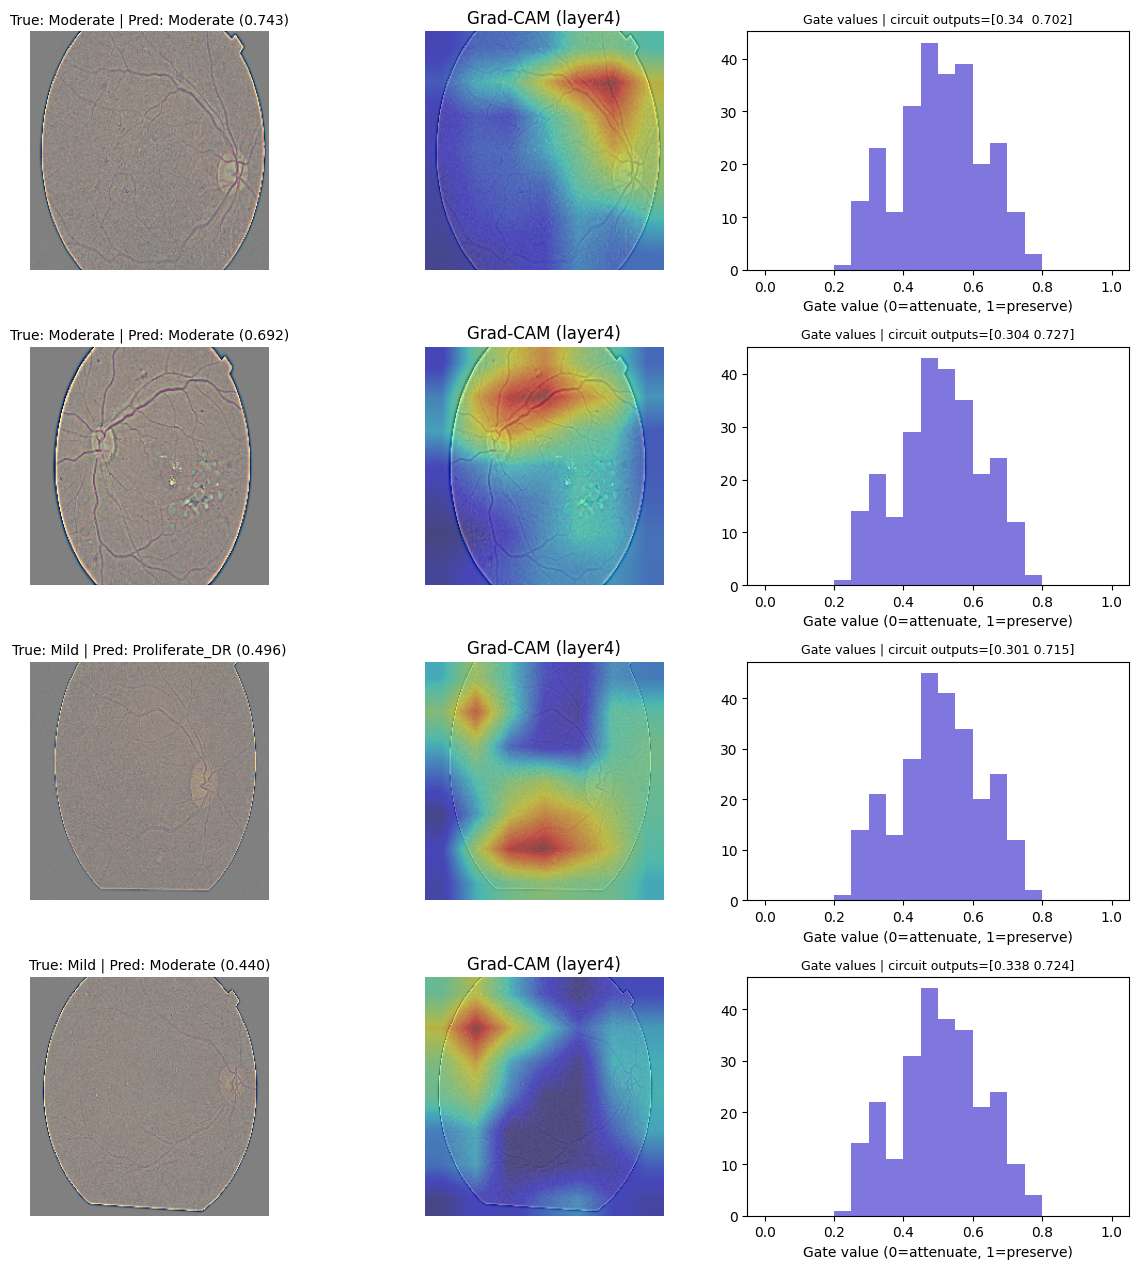

Updated results archive, including explainability:


/kaggle/working/checkpoints/quantum_gated_diabetic_retinopathy_20260902_122112_c25e9a98.zip

In [16]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self.handle = target_layer.register_forward_hook(self._save_activation)

    def _save_activation(self, module, inputs, output):
        self.activations = output.detach()
        # Tensor hook avoids module backward-hook/in-place interactions.
        if output.requires_grad:
            output.register_hook(self._save_gradient)

    def _save_gradient(self, gradient):
        self.gradients = gradient.detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        self.activations = self.gradients = None
        self.model.zero_grad(set_to_none=True)
        with torch.enable_grad():
            logits = self.model(input_tensor)
            probabilities = F.softmax(logits, dim=1)
            if class_idx is None:
                class_idx = int(probabilities.argmax(dim=1).item())
            logits[0, class_idx].backward()
        if self.gradients is None or self.activations is None:
            raise RuntimeError("Grad-CAM did not capture activations/gradients.")
        gradients = self.gradients[0]
        activations = self.activations[0]
        weights = gradients.mean(dim=(1, 2))
        cam = torch.relu((weights[:, None, None] * activations).sum(0))
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy(), class_idx, probabilities[0, class_idx].item()

    def close(self):
        self.handle.remove()
        self.activations = self.gradients = None

N_SAMPLES = min(4, len(val_dataset))
sample_indices = np.random.RandomState(SEED).choice(len(val_dataset), N_SAMPLES, replace=False)
gate_capture, quantum_capture = {}, {}
gate_handle = gated_model.excite.register_forward_hook(
    lambda module, inputs, output: gate_capture.update(gate=output.detach().cpu())
)
quantum_handle = gated_model.quantum.register_forward_hook(
    lambda module, inputs, output: quantum_capture.update(q=output.detach().cpu())
)
gradcam = GradCAM(gated_model, gated_model.layer4)
explanation_rows = []
fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(12, 3.2 * N_SAMPLES), squeeze=False)
try:
    for row, idx in enumerate(sample_indices):
        img_tensor, label = val_dataset[int(idx)]
        full_idx = val_dataset.indices[int(idx)]
        metadata_row = full_dataset.df.iloc[full_idx]
        with Image.open(metadata_row["filepath"]) as image:
            raw_img = np.array(T.Resize((IMG_SIZE, IMG_SIZE))(image.convert("RGB")))
        cam, pred_idx, pred_prob = gradcam.generate(img_tensor.unsqueeze(0).to(DEVICE))
        cam_resized = F.interpolate(
            torch.from_numpy(cam)[None, None],
            size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False
        )[0, 0].numpy()
        gate_vals = gate_capture["gate"][0].numpy()
        q_vals = quantum_capture["q"][0].numpy()
        assert gate_vals.shape == (256,) and q_vals.shape == (N_QUBITS,)
        assert np.isfinite(cam_resized).all() and np.isfinite(gate_vals).all()
        assert ((gate_vals >= 0) & (gate_vals <= 1)).all()
        axes[row, 0].imshow(raw_img)
        axes[row, 0].set_title(
            f"True: {CLASS_NAMES[int(label)]} | Pred: {CLASS_NAMES[pred_idx]} ({pred_prob:.3f})",
            fontsize=10,
        )
        axes[row, 0].axis("off")
        axes[row, 1].imshow(raw_img)
        axes[row, 1].imshow(cam_resized, cmap="jet", alpha=0.45, vmin=0, vmax=1)
        axes[row, 1].set_title("Grad-CAM (layer4)")
        axes[row, 1].axis("off")
        axes[row, 2].hist(gate_vals, bins=20, range=(0, 1), color="#7F77DD")
        axes[row, 2].set_title(f"Gate values | circuit outputs={np.round(q_vals, 3)}", fontsize=9)
        axes[row, 2].set_xlabel("Gate value (0=attenuate, 1=preserve)")
        explanation_rows.append({
            "image_id": metadata_row["image_id"], "true_label": int(label),
            "predicted_label": pred_idx, "predicted_probability": pred_prob,
            **{f"quantum_output_{i}": float(v) for i, v in enumerate(q_vals)},
            **{f"gate_channel_{i}": float(v) for i, v in enumerate(gate_vals)},
        })
    plt.tight_layout()
    plt.savefig(RUN_DIR / "explainability_examples.png", dpi=160)
    pd.DataFrame(explanation_rows).to_csv(RUN_DIR / "explainability_values.csv", index=False)
    plt.show()
finally:
    gradcam.close()
    gate_handle.remove()
    quantum_handle.remove()
    gated_model.zero_grad(set_to_none=True)
    plt.close(fig)

# Refresh the existing ZIP to include the explanation files.
archive_path = shutil.make_archive(str(RUN_DIR), "zip", root_dir=RUN_DIR)
print("Updated results archive, including explainability:")
display(FileLink(os.path.relpath(archive_path, Path.cwd())))